Data Loading and Label Mapping

In [1]:
!pip install -q datasets pandas

import pandas as pd
from datasets import load_dataset

dataset = load_dataset("google-research-datasets/go_emotions", "simplified")

raw_emotions = dataset['train'].features['labels'].feature.names

mapping = {
    'joy': ['joy', 'amusement', 'approval', 'excitement', 'gratitude', 'love', 'pride', 'relief', 'optimism'],
    'sadness': ['sadness', 'disappointment', 'grief', 'remorse'],
    'anger': ['anger', 'annoyance', 'disapproval'],
    'fear': ['fear', 'nervousness'],
    'surprise': ['surprise', 'realization', 'confusion'],
    'disgust': ['disgust']
}

target_emotions = ['joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust']
emotion_to_id = {emotion: idx for idx, emotion in enumerate(target_emotions)}

id_mapping = {}
for orig_idx, orig_name in enumerate(raw_emotions):
    for target_name, group in mapping.items():
        if orig_name in group:
            id_mapping[orig_idx] = emotion_to_id[target_name]
            break

def filter_and_map(example):
    if len(example['labels']) == 1:
        orig_label = example['labels'][0]
        if orig_label in id_mapping:
            return {'text': example['text'], 'label': id_mapping[orig_label]}
    return {'text': None, 'label': None}

processed_dataset = dataset.map(filter_and_map)

train_df = pd.DataFrame(processed_dataset['train']).dropna()
val_df = pd.DataFrame(processed_dataset['validation']).dropna()
test_df = pd.DataFrame(processed_dataset['test']).dropna()

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(train_df.head())

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.77MB            

simplified/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

simplified/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  350kB            

simplified/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Train samples: 18145
Validation samples: 2298
Test samples: 2295
                                                text labels       id  label
2                     WHY THE FUCK IS BAYLESS ISOING    [2]  eezlygj    2.0
3                        To make her feel threatened   [14]  ed7ypvh    3.0
4                             Dirty Southern Wankers    [3]  ed0bdzj    2.0
5  OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...   [26]  edvnz26    4.0
6  Yes I heard abt the f bombs! That has to be wh...   [15]  ee3b6wu    0.0


Text Preprocessing and GloVe Embeddings

In [2]:
!pip install -q nltk

import torch
import torch.nn as nn
import numpy as np
import os
import urllib.request
import zipfile
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

def clean_text(text):
    text = text.lower()
    return " ".join(word_tokenize(text))

train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text'] = val_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

word2idx = {"<PAD>": 0, "<UNK>": 1}
idx = 2

for text in train_df['clean_text']:
    for word in text.split():
        if word not in word2idx:
            word2idx[word] = idx
            idx += 1

vocab_size = len(word2idx)

if not os.path.exists('glove.6B.100d.txt'):
    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    urllib.request.urlretrieve(url, "glove.6B.zip")
    with zipfile.ZipFile("glove.6B.zip", 'r') as zip_ref:
        zip_ref.extractall(".")

embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word2idx.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
    else:
        if i != 0:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

print(f"Vocab Size: {vocab_size}")
print(f"Embedding Matrix Shape: {embedding_matrix.shape}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Vocab Size: 17113
Embedding Matrix Shape: torch.Size([17113, 100])


PyTorch Dataset, DataLoaders, and Model Architectures

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class EmotionDataset(Dataset):
    def __init__(self, df, word2idx, max_len=50):
        self.texts = df['clean_text'].values
        self.labels = df['label'].values.astype(int)
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = text.split()
        seq = [self.word2idx.get(w, self.word2idx["<UNK>"]) for w in tokens][:self.max_len]
        padding = [self.word2idx["<PAD>"]] * (self.max_len - len(seq))
        seq = seq + padding
        return torch.tensor(seq, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

max_len = 50
batch_size = 32

train_dataset = EmotionDataset(train_df, word2idx, max_len)
val_dataset = EmotionDataset(val_df, word2idx, max_len)
test_dataset = EmotionDataset(test_df, word2idx, max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class LSTMModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        out = self.fc(h_n[-1])
        return out

class GRUModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, h_n = self.gru(embedded)
        out = self.fc(h_n[-1])
        return out

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, encoder_outputs, mask=None):
        energy = torch.tanh(self.attn(encoder_outputs))
        weights = self.v(energy).squeeze(-1)
        if mask is not None:
            weights = weights.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(weights, dim=-1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_weights

class BiLSTMAttentionModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes, pad_idx=0):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False)
        self.bilstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = Attention(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        mask = (x != self.pad_idx)
        embedded = self.embedding(x)
        lstm_out, _ = self.bilstm(embedded)
        context, attn_weights = self.attention(lstm_out, mask)
        out = self.fc(context)
        return out, attn_weights

print("DataLoaders and 3 Custom Models defined successfully!")

DataLoaders and 3 Custom Models defined successfully!


Training and Evaluation Loop

In [4]:
from sklearn.metrics import accuracy_score, f1_score
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def train_epoch(model, loader, criterion, optimizer, is_attention=False):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        if is_attention:
            out, _ = model(x)
        else:
            out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(out, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1

def evaluate(model, loader, criterion, is_attention=False):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if is_attention:
                out, _ = model(x)
            else:
                out = model(x)

            loss = criterion(out, y)
            total_loss += loss.item()

            preds = torch.argmax(out, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1, all_preds, all_labels

# Parameters
hidden_dim = 128
num_classes = 6
epochs = 5
lr = 0.001
criterion = nn.CrossEntropyLoss()

# Initialize Models
models = {
    "LSTM": LSTMModel(embedding_matrix, hidden_dim, num_classes).to(device),
    "GRU": GRUModel(embedding_matrix, hidden_dim, num_classes).to(device),
    "BiLSTM_Attention": BiLSTMAttentionModel(embedding_matrix, hidden_dim, num_classes).to(device)
}

results = {}

for name, model in models.items():
    print(f"\n================ Training {name} ================")
    optimizer = optim.Adam(model.parameters(), lr=lr)
    is_attn = (name == "BiLSTM_Attention")

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, is_attention=is_attn)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, is_attention=is_attn)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} - Acc: {val_acc:.4f} - F1: {val_f1:.4f}")

    test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, is_attention=is_attn)
    print(f"---> {name} Test Results -> Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | Macro F1: {test_f1:.4f}")

    results[name] = {
        "model": model,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "preds": test_preds,
        "labels": test_labels
    }

Using device: cuda

================ Training LSTM ================
Epoch 1/5 | Train Loss: 1.3825 - Acc: 0.5030 - F1: 0.1134 | Val Loss: 1.3475 - Acc: 0.5196 - F1: 0.1140
Epoch 2/5 | Train Loss: 1.3674 - Acc: 0.5055 - F1: 0.1119 | Val Loss: 1.3451 - Acc: 0.5196 - F1: 0.1140
Epoch 3/5 | Train Loss: 1.3667 - Acc: 0.5055 - F1: 0.1119 | Val Loss: 1.3490 - Acc: 0.5196 - F1: 0.1140
Epoch 4/5 | Train Loss: 1.3668 - Acc: 0.5055 - F1: 0.1119 | Val Loss: 1.3464 - Acc: 0.5196 - F1: 0.1140
Epoch 5/5 | Train Loss: 1.3694 - Acc: 0.5055 - F1: 0.1119 | Val Loss: 1.3482 - Acc: 0.5196 - F1: 0.1140
---> LSTM Test Results -> Loss: 1.4029 | Acc: 0.4850 | Macro F1: 0.1089

================ Training GRU ================
Epoch 1/5 | Train Loss: 1.2123 - Acc: 0.5474 - F1: 0.2057 | Val Loss: 0.9550 - Acc: 0.6414 - F1: 0.2979
Epoch 2/5 | Train Loss: 0.8790 - Acc: 0.6759 - F1: 0.4164 | Val Loss: 0.7788 - Acc: 0.7258 - F1: 0.5887
Epoch 3/5 | Train Loss: 0.6587 - Acc: 0.7770 - F1: 0.6410 | Val Loss: 0.7110 - Acc: 

HuggingFace Transformers Integration & Fine-Tuning

In [7]:
# 1. تثبيت واستدعاء المكتبات الخاصة بـ HuggingFace
!pip install -q transformers evaluate

import torch
import numpy as np
import evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# 2. تحضير الـ Tokenizer والموديل (DistilBERT)
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# تجهيز البيانات والتأكد من نوع الـ label أنه Integer
train_df_hf = train_df[['clean_text', 'label']].rename(columns={'clean_text': 'text'}).copy()
val_df_hf = val_df[['clean_text', 'label']].rename(columns={'clean_text': 'text'}).copy()
test_df_hf = test_df[['clean_text', 'label']].rename(columns={'clean_text': 'text'}).copy()

train_df_hf['label'] = train_df_hf['label'].astype(int)
val_df_hf['label'] = val_df_hf['label'].astype(int)
test_df_hf['label'] = test_df_hf['label'].astype(int)

train_hf = Dataset.from_pandas(train_df_hf)
val_hf = Dataset.from_pandas(val_df_hf)
test_hf = Dataset.from_pandas(test_df_hf)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=50)

tokenized_train = train_hf.map(tokenize_function, batched=True)
tokenized_val = val_hf.map(tokenize_function, batched=True)
tokenized_test = test_hf.map(tokenize_function, batched=True)

# 3. دالة حساب المقاييس (Accuracy & Macro F1)
f1_metric = evaluate.load("f1")
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = acc_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1": f1}

# 4. تحميل الموديل وتأكيد معلمات الـ Single-Label Classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=6,
    problem_type="single_label_classification"
)

training_args = TrainingArguments(
    output_dir="./distilbert_emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# 5. تدريب وتقييم DistilBERT
print("================ Training DistilBERT ================")
trainer.train()

# التقييم على Test Set
test_results = trainer.evaluate(tokenized_test)
print(f"\n---> DistilBERT Test Results -> Accuracy: {test_results['eval_accuracy']:.4f} | Macro F1: {test_results['eval_f1']:.4f}")

Map:   0%|          | 0/18145 [00:00<?, ? examples/s]

Map:   0%|          | 0/2298 [00:00<?, ? examples/s]

Map:   0%|          | 0/2295 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.469821,0.610247,3,0.796950,0.710590



---> DistilBERT Test Results -> Accuracy: 0.7969 | Macro F1: 0.7106


(Model Interpretability & Visualization)

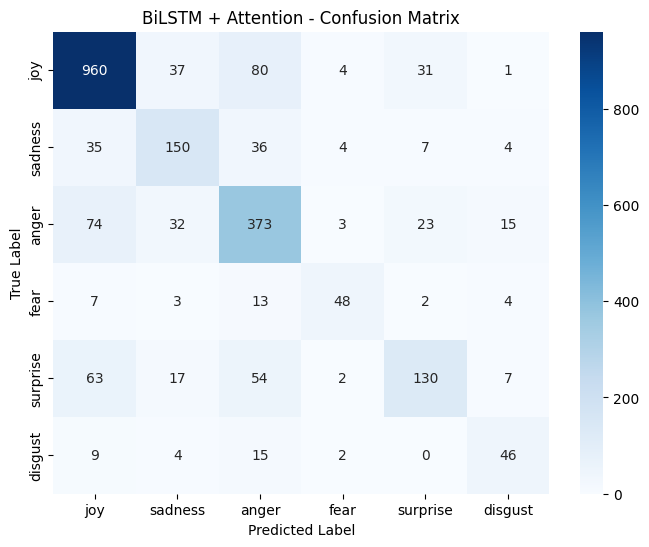

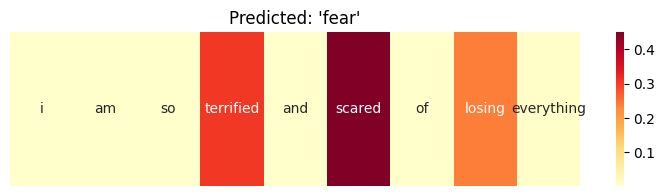

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

emotion_labels = ['joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust']


plt.figure(figsize=(8, 6))
cm = confusion_matrix(results['BiLSTM_Attention']['labels'], results['BiLSTM_Attention']['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title('BiLSTM + Attention - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


def visualize_attention(text, model, word2idx, max_len=50):
    model.eval()
    tokens = text.lower().split()
    seq = [word2idx.get(w, word2idx["<UNK>"]) for w in tokens][:max_len]
    padded_seq = seq + [word2idx["<PAD>"]] * (max_len - len(seq))

    input_tensor = torch.tensor([padded_seq], dtype=torch.long).to(device)

    with torch.no_grad():
        out, attn_weights = model(input_tensor)
        pred_idx = torch.argmax(out, dim=1).item()

    attn_weights = attn_weights[0][:len(tokens)].cpu().numpy()


    plt.figure(figsize=(len(tokens) * 0.8 + 2, 2))
    sns.heatmap([attn_weights], annot=[tokens], fmt='', cmap='YlOrRd', cbar=True,
                xticklabels=False, yticklabels=False)
    plt.title(f"Predicted: '{emotion_labels[pred_idx]}'")
    plt.show()


sample_text = "i am so terrified and scared of losing everything"
visualize_attention(sample_text, results['BiLSTM_Attention']['model'], word2idx)

In [26]:
import torch


torch.save(bilstm_model.state_dict(), 'bilstm_model.pth')
print(" تم حفظ الموديل بنجاح!")

 تم حفظ الموديل بنجاح!


GUI

In [25]:
!pip install -q gradio

import gradio as gr
import torch
import torch.nn.functional as F
import numpy as np

bilstm_model = results['BiLSTM_Attention']['model']
bilstm_model.eval()

EMOTION_CONFIG = {
    'anger': {'emoji': '😡', 'color': '#ff5252'},
    'sadness': {'emoji': '😢', 'color': '#0088ff'},
    'disgust': {'emoji': '🤢', 'color': '#00e5a3'},
    'joy': {'emoji': '😊', 'color': '#ffbe0b'},
    'surprise': {'emoji': '😲', 'color': '#e056fd'},
    'fear': {'emoji': '😨', 'color': '#ff7043'}
}

def analyze_full_dashboard(text):
    if not text or not text.strip():
        empty_card = "<div style='text-align:center; padding:15px; color:#b3a4c9;'>Enter or select text to analyze...</div>"
        empty_attn = "<div style='text-align:center; padding:10px; color:#b3a4c9;'>Word attention weights will appear here...</div>"
        return empty_card, {}, empty_attn

    try:
        tokens = text.lower().split()
        seq = [word2idx.get(w, word2idx["<UNK>"]) for w in tokens][:50]
        padded_seq = seq + [word2idx["<PAD>"]] * (50 - len(seq))

        input_tensor = torch.tensor([padded_seq], dtype=torch.long).to(device)

        with torch.no_grad():
            out, attn_weights = bilstm_model(input_tensor)
            probs = F.softmax(out, dim=1).squeeze(0).cpu().numpy()

        top_idx = np.argmax(probs)
        top_emotion = emotion_labels[top_idx]
        top_prob = probs[top_idx] * 100

        cfg = EMOTION_CONFIG.get(top_emotion, {'emoji': '🎭', 'color': '#0088ff'})


        prediction_html = f"""
        <div style="background: #2a1b3d; border-radius: 12px; padding: 15px; text-align: center; border: 1px solid #5e3a8c; box-shadow: 0 4px 20px rgba(0,0,0,0.4);">
            <div style="font-size: 2.8rem; margin-bottom: 2px;">{cfg['emoji']}</div>
            <div style="font-size: 0.75rem; text-transform: uppercase; letter-spacing: 1px; color: #b3a4c9; font-weight: 600;">Predicted Emotion</div>
            <div style="font-size: 1.6rem; font-weight: 800; color: {cfg['color']}; margin: 2px 0;">{top_emotion.upper()}</div>
            <div style="font-size: 0.75rem; color: #b3a4c9;">Confidence Score</div>
            <div style="font-size: 1.8rem; font-weight: 800; color: #ffffff;">{top_prob:.1f}%</div>
            <div style="display: inline-block; margin-top: 6px; padding: 3px 10px; background: rgba(0, 229, 163, 0.15); color: #00e5a3; border: 1px solid #00e5a3; border-radius: 15px; font-weight: 600; font-size: 0.75rem;">
                ✓ High Confidence Prediction
            </div>
        </div>
        """


        confidences = {f"{EMOTION_CONFIG.get(emo, {}).get('emoji', '')} {emo.capitalize()}": float(probs[i]) for i, emo in enumerate(emotion_labels)}


        weights_seq = attn_weights[0][:len(tokens)].cpu().numpy()
        max_w = max(weights_seq) if max(weights_seq) > 0 else 1.0

        words_html_list = []
        for word, weight in zip(tokens, weights_seq):
            norm_w = weight / max_w
            bg_alpha = min(max(norm_w, 0.1), 0.95)
            if norm_w > 0.5:
                badge_style = f"background: rgba(255, 82, 82, {bg_alpha}); color: #fff; font-weight: bold; border: 1px solid #ff5252;"
            else:
                badge_style = f"background: rgba(255, 255, 255, {bg_alpha * 0.15}); color: #b3a4c9; border: 1px solid rgba(255, 255, 255, 0.1);"

            words_html_list.append(f'<span style="display:inline-block; margin: 3px; padding: 3px 8px; border-radius: 6px; font-size: 0.85rem; {badge_style}">{word}</span>')

        attention_html = f"""
        <div style="background: #2a1b3d; border-radius: 12px; padding: 12px; border: 1px solid #5e3a8c;">
            <div style="font-size: 0.75rem; color: #b3a4c9; margin-bottom: 6px; font-weight: 600;">Highlighted words contributed most:</div>
            <div style="line-height: 1.6rem; text-align: left;">
                {' '.join(words_html_list)}
            </div>
            <div style="margin-top: 8px; display: flex; align-items: center; justify-content: space-between; font-size: 0.65rem; color: #888;">
                <span>Low Attention</span>
                <div style="height: 4px; flex-grow: 1; margin: 0 8px; background: linear-gradient(90deg, rgba(255,255,255,0.1), #ff5252); border-radius: 2px;"></div>
                <span>High Attention</span>
            </div>
        </div>
        """

        return prediction_html, confidences, attention_html

    except Exception as e:
        err_html = f"<div style='color:#ff5252; padding:10px;'>Error: {str(e)}</div>"
        return err_html, {}, err_html


custom_css = """
body {
    background-color: #120a1b !important;
    display: flex;
    justify-content: center;
    align-items: center;
    min-height: 100vh;
    padding: 0;
    margin: 0;
}

.gradio-container {
    width: 1846px !important;
    min-width: 1846px !important;
    max-width: 1846px !important;
    height: 800px !important;
    min-height: 800px !important;
    max-height: 800px !important;
    background-color: #1e132b !important;
    font-family: 'Inter', sans-serif;
    color: #ffffff;
    border-radius: 16px;
    border: 1px solid #4a286e;
    box-shadow: 0 10px 40px rgba(0,0,0,0.6);
    padding: 16px 24px 40px 24px !important; /* إضافة padding من الأسفل */
    box-sizing: border-box;
    overflow-y: auto !important;
}

.metric-card { background: #2a1b3d; border-radius: 10px; padding: 10px 14px; border: 1px solid #4a286e; text-align: left; }
.metric-title { font-size: 0.7rem; color: #b3a4c9; font-weight: 600; text-transform: uppercase; margin-bottom: 2px; }
.metric-val { font-size: 1.3rem; font-weight: 800; color: #ffffff; }
.metric-sub { font-size: 0.65rem; color: #00e5a3; font-weight: 600; margin-top: 1px; }
.section-box { background: #2a1b3d !important; border-radius: 10px; padding: 12px; border: 1px solid #4a286e; margin-bottom: 0px; }
.section-title { font-size: 0.85rem; font-weight: 700; color: #ffffff; margin-bottom: 8px; display: flex; align-items: center; gap: 6px; }
.badge-num { background: #0088ff; color: white; border-radius: 50%; width: 18px; height: 18px; display: inline-flex; align-items: center; justify-content: center; font-size: 0.65rem; font-weight: bold; }

textarea, input { background-color: #1a0f26 !important; color: #ffffff !important; border: 1px solid #5e3a8c !important; font-size: 0.85rem !important; }
button.primary { background: linear-gradient(90deg, #0088ff 0%, #00e5a3 100%) !important; border: none !important; color: #ffffff !important; font-weight: bold !important; font-size: 0.85rem !important; }
button.secondary { background: #3d235a !important; color: #ffffff !important; border: 1px solid #5e3a8c !important; font-size: 0.85rem !important; }
"""

with gr.Blocks(title="EmotiClass AI") as demo:


    with gr.Row():
        with gr.Column(scale=9):
            gr.Markdown("""
            #    <span style="color:#0088ff;">EmotiClass</span> <span style="color:#00e5a3;">AI</span> — <span style="font-size:0.9rem; font-weight:normal; color:#b3a4c9;">Advanced Emotion Classification with BiLSTM + Attention</span>
            """, elem_id="header-title")
        with gr.Column(scale=1, min_width=80):
            gr.Markdown("<span style='color:#b3a4c9; float:right;'>(v1.2)</span>")


    with gr.Row():
        with gr.Column(scale=3):
            gr.HTML('<div class="metric-card"><div class="metric-title">Accuracy</div><div class="metric-val" style="color:#0088ff;">74.4%</div><div class="metric-sub">BiLSTM+Attn</div></div>')
        with gr.Column(scale=3):
            gr.HTML('<div class="metric-card"><div class="metric-title">Classes</div><div class="metric-val" style="color:#e056fd;">6</div><div class="metric-sub" style="color:#b3a4c9;">Categories</div></div>')
        with gr.Column(scale=3):
            gr.HTML('<div class="metric-card"><div class="metric-title">Architecture</div><div class="metric-val" style="font-size: 1rem; line-height:1.2rem; color:#00e5a3;">BiLSTM</div><div class="metric-sub" style="color:#b3a4c9;">+ Attention</div></div>')
        with gr.Column(scale=3):
            gr.HTML('<div class="metric-card"><div class="metric-title">Macro F1</div><div class="metric-val" style="color:#ffbe0b;">66.7%</div><div class="metric-sub">Score</div></div>')


    with gr.Row():

        with gr.Column(scale=4):
            with gr.Group(elem_classes=["section-box"]):
                gr.HTML('<div class="section-title"><span class="badge-num">1</span> Enter Your Text</div>')
                input_text = gr.Textbox(
                    lines=3,
                    placeholder="Type or paste text...",
                    show_label=False
                )

                gr.Markdown("**Quick Examples**")
                ex1 = gr.Button(" This is completely unacceptable!", size="sm")
                ex2 = gr.Button(" I finally achieved my dream.", size="sm")
                ex3 = gr.Button(" I miss my family so much.", size="sm")
                ex4 = gr.Button(" Wow! I wasn't expecting that!", size="sm")

                with gr.Row():
                    analyze_btn = gr.Button(" Analyze Emotion", variant="primary")
                    clear_btn = gr.Button("🗑️ Clear", variant="secondary")


        with gr.Column(scale=4):
            with gr.Group(elem_classes=["section-box"]):
                gr.HTML('<div class="section-title"><span class="badge-num">2</span> Prediction Result</div>')
                pred_output = gr.HTML("<div style='text-align:center; padding:15px; color:#b3a4c9;'>Ready...</div>")

        with gr.Column(scale=4):
            with gr.Group(elem_classes=["section-box"]):
                gr.HTML('<div class="section-title"><span class="badge-num">3</span> Emotion Probabilities</div>')
                probs_output = gr.Label(num_top_classes=6, show_label=False)


    with gr.Row():
        with gr.Column(scale=12):
            with gr.Group(elem_classes=["section-box"]):
                gr.HTML('<div class="section-title"><span class="badge-num">4</span> Attention Visualization</div>')
                attention_output = gr.HTML("<div style='text-align:center; padding:10px; color:#b3a4c9;'>Attention weights will appear here...</div>")


    gr.HTML("""
    <div style="text-align: center; font-size: 0.75rem; color: #b3a4c9; margin-top: 15px;">
        © 2026 EmotiClass AI • Developed by Mohamed Ashraf
    </div>
    """)


    gr.HTML('<div style="height: 40px;"></div>')


    analyze_btn.click(
        fn=analyze_full_dashboard,
        inputs=input_text,
        outputs=[pred_output, probs_output, attention_output]
    )

    ex1.click(lambda: "This is completely unacceptable and makes me extremely furious.", outputs=input_text).then(
        fn=analyze_full_dashboard, inputs=input_text, outputs=[pred_output, probs_output, attention_output]
    )
    ex2.click(lambda: "I finally achieved my dream.", outputs=input_text).then(
        fn=analyze_full_dashboard, inputs=input_text, outputs=[pred_output, probs_output, attention_output]
    )
    ex3.click(lambda: "I miss my family so much.", outputs=input_text).then(
        fn=analyze_full_dashboard, inputs=input_text, outputs=[pred_output, probs_output, attention_output]
    )
    ex4.click(lambda: "Wow! I wasn't expecting that!", outputs=input_text).then(
        fn=analyze_full_dashboard, inputs=input_text, outputs=[pred_output, probs_output, attention_output]
    )

    clear_btn.click(lambda: "", outputs=input_text)

demo.launch(css=custom_css, share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ecfdb1c549943ae2ad.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ecfdb1c549943ae2ad.gradio.live
